In [ ]:
##########################Load Libraries  ####################################
import pandas as pd
import numpy as np
# import dask.dataframe as dd

import matplotlib.pyplot as plt
# import seaborn as sns
import lightgbm as lgb
from sklearn import preprocessing, metrics
from ipywidgets import widgets, interactive
import gc
import joblib
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
from typing import Union
from tqdm.notebook import tqdm_notebook as tqdm
from itertools import cycle
import datetime as dt
from torch.autograd import Variable
import random
import os
from matplotlib.pyplot import figure
from fastprogress import master_bar, progress_bar
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import time
import torch.nn.functional as F
from torch.utils.data import Dataset
from sklearn.metrics import mean_squared_error
import torch
from sklearn.model_selection import TimeSeriesSplit

from math import log
from math import exp
from scipy.stats import boxcox


import torch.optim as optim

%matplotlib inline

#from gensim.models import Word2Vec
#import gensim.downloader as api

# pd.set_option('max_columns', 50)
# plt.style.use('bmh')
# color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']
# color_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

from torch.utils.data import TensorDataset, DataLoader




In [ ]:
import scipy

# Data Pre-process

## Download data and exploration
The time series data alread pre-precess into sequency, and saved as .npy files.

shape of X: 15400,120,4

shape of Y: 15400,120

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X = np.load("/content/drive/MyDrive/Deeplearning/X.npy")

In [ ]:
Y = np.load("/content/drive/MyDrive/Deeplearning/Y.npy")

In [ ]:
Z = np.load("/content/drive/MyDrive/Deeplearning/Z.npy")

In [ ]:
X = np.float32(X)
Y = np.float32(Y)
Z = np.float32(Z)

Text(0, 0.5, 'anomaly index')

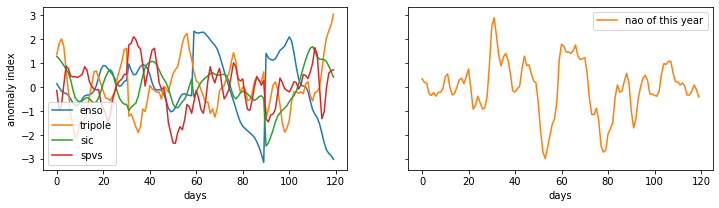

In [ ]:
fig,axes = plt.subplots(1,2,figsize = (12,3),sharey = True)
axes[0].plot(X[0],)
# axes[1].plot(Y[0],label = "nao of next year")
axes[1].plot(Z[0],label = "nao of this year",color ='#ff7f0e' )

axes[0].legend(['enso','tripole','sic','spvs'])
axes[1].legend()
axes[0].set_xlabel("days")
axes[1].set_xlabel("days")

axes[0].set_ylabel("anomaly index")


Text(0, 0.5, 'anomaly index')

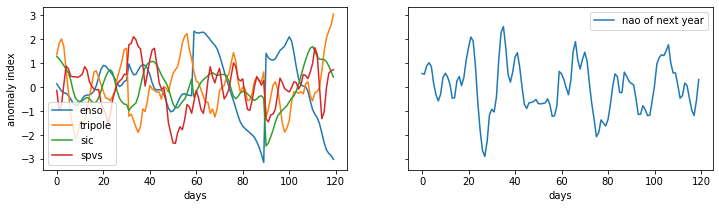

In [ ]:
fig,axes = plt.subplots(1,2,figsize = (12,3),sharey = True)
axes[0].plot(X[0],)
axes[1].plot(Y[0],label = "nao of next year")
# axes[1].plot(Z[0],label = "nao of this year",color ='#ff7f0e' )

axes[0].legend(['enso','tripole','sic','spvs'])
axes[1].legend()
axes[0].set_xlabel("days")
axes[1].set_xlabel("days")

axes[0].set_ylabel("anomaly index")

## normalize

In [ ]:
X = (X-X.min(axis = 0))/(X.max(axis = 0)-X.min(axis = 0))

In [ ]:
Y = (Y-Y.min(axis = 0))/(Y.max(axis = 0)-Y.min(axis = 0))

In [ ]:
Z = (Z-Z.min(axis = 0))/(Z.max(axis = 0)-Z.min(axis = 0))

In [ ]:
# Z = Z[:,0]  # ONLY the first one

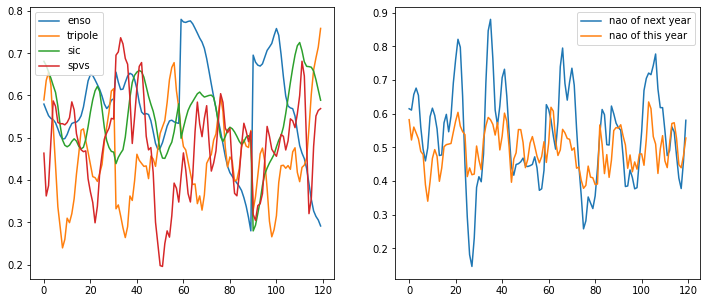

In [ ]:
fig,axes = plt.subplots(1,2,figsize = (12,5))
axes[0].plot(X[0],)
axes[1].plot(Y[0],label = "nao of next year")
axes[1].plot(Z[1],label = "nao of this year")
axes[0].legend(['enso','tripole','sic','spvs'])
axes[1].legend()

## Train data and test data

In [ ]:
X = torch.from_numpy(X)
Y = torch.from_numpy(Y)
Z = torch.from_numpy(Z)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device is:",device)

device is: cpu


In [ ]:
# print(torch.cuda.get_device_name(0))
# device = torch.device('cuda:0')
X = X.to(device)
Y = Y.to(device)
Z = Z.to(device)

In [ ]:
def loader_dataset(x,y,z,batch_size = 200):

    full_dataset = TensorDataset(x, y, z)  # combine the inputs and outputs into a PyTorch Dataset object

    # size
    train_size = int(0.7 * len(full_dataset))
    valid_size = int(0.2*len(full_dataset))
    test_size = len(full_dataset) - train_size - valid_size

    # split
    train_dataset, valid_dataset,test_dataset = torch.utils.data.random_split(full_dataset, [train_size,valid_size, test_size])
    print(len(train_dataset))
    print(len(valid_dataset))
    print(len(test_dataset))
    # data loader
    train_loader = DataLoader(
          train_dataset,
          batch_size=batch_size,
          shuffle=True)

    valid_loader = DataLoader(
        valid_dataset,
        batch_size = batch_size,
        shuffle = True
    )

    test_loader = DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=True)
    return train_loader,valid_loader,test_loader

In [ ]:
train_loader,valid_loader,test_loader = loader_dataset(X,Y,Z)

10780
3080
1540


In [ ]:
len(test_loader)

8

# Model and Training

## model define

### Encoder

In [ ]:
class Encoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim,num_layers ):
        super(Encoder, self).__init__()

        self.seq_len, self.n_features = seq_len, n_features
        self.hidden_dim = embedding_dim
        self.num_layers = num_layers
        self.rnn1 = nn.LSTM(
          input_size=n_features,
          hidden_size=self.hidden_dim,
          num_layers=num_layers,
          batch_first=True,
          dropout = 0.1
        )


    def forward(self, x):

        # x = x.reshape((1, self.seq_len, self.n_features))

        h_1 = Variable(torch.zeros(
            self.num_layers, x.size(0), self.hidden_dim).to(device))


        c_1 = Variable(torch.zeros(
            self.num_layers, x.size(0), self.hidden_dim).to(device))

        x, (hidden, cell) = self.rnn1(x,(h_1, c_1))


        #return hidden_n.reshape((self.n_features, self.embedding_dim))
        return x,hidden , cell


### Decoder

In [ ]:
class Decoder(nn.Module):
    def __init__(self, seq_len, input_dim=64, n_features=1,num_layers=3):
        super(Decoder, self).__init__()

        self.seq_len, self.input_dim = seq_len, input_dim
        self.hidden_dim, self.n_features =  input_dim, n_features

        self.rnn1 = nn.LSTM(
          input_size=1,
          hidden_size=input_dim,
          num_layers=num_layers,
          batch_first=True,
          dropout = 0.1
        )


        self.tanh = nn.Tanh()
        self.output_layer1 = nn.Linear(self.hidden_dim, 1)
        self.bn1 = nn.BatchNorm1d(1,affine=False)

        self.output_layer2 = nn.Linear(self.hidden_dim,1)


    def forward(self, x,input_hidden,input_cell):


        x = x.reshape((-1,1,1 ))


        x, (hidden_n, cell_n) = self.rnn1(x,(input_hidden,input_cell))

        x = self.output_layer1(x)
        # x = self.bn1(x)

        x = self.tanh(x)
        # x = x.reshape(x.size()[0],x.size()[-1])
        # x = self.bn1(x)

        # x = self.tanh(x)
        # x = self.output_layer2(x)


        return x, hidden_n, cell_n

### Seq2seq

In [ ]:
class Seq2Seq(nn.Module):

    def __init__(self, seq_len, n_features, embedding_dim=128,output_length = 120,num_layers = 9):
        super(Seq2Seq, self).__init__()

        self.encoder = Encoder(seq_len, n_features, embedding_dim,num_layers).to(device)
        self.n_features = n_features
        self.output_length = output_length
        self.decoder = Decoder(seq_len, embedding_dim, n_features,num_layers).to(device)
        self.tanh = nn.Tanh()
        self.output_layer1 = nn.Linear(1, embedding_dim)
        self.output_layer2 = nn.Linear(embedding_dim,1)
        self.conv1d = nn.Conv1d(in_channels = 2, out_channels=1,kernel_size = 1)
        self.bn = nn.BatchNorm1d(1)

    def forward(self,x, ref_nao):


        encode_ouput,hidden,cell = self.encoder(x)

        #Prepare place holder for decoder output
        targets_ta = []
        #prev_output become the next input to the LSTM cell

        # ref_y = ref_nao.reshape(-1,1)  # reference value
        # ref_y = self.output_layer1(ref_y)
        # ref_y = self.tanh(ref_y)
        # ref_y = self.output_layer2(ref_y)

        ref_y = ref_nao[:,0]
        dh0 = hidden
        dc0 = cell

       #dec_input = torch.cat([prev_output, curr_features], dim=1)

        #itearate over LSTM - according to the required output days
        for out_days in range(self.output_length) :
            x,prev_hidden,prev_cell = self.decoder(ref_y,dh0,dc0)

            # print("decode output shape:", prev_x.size())
            dh0 = prev_hidden
            dco = prev_cell


            if out_days+1 < self.output_length:
                ref_y = torch.cat([x,ref_nao[:,out_days+1].reshape(ref_nao[:,out_days+1].size()[0],1,1)],dim = 1)
                ref_y = self.conv1d(ref_y)
                # ref_y = self.bn(ref_y)
                ref_y = self.tanh(ref_y)


            targets_ta.append(x.reshape(-1))

            # print(out_days)


        targets = torch.stack(targets_ta)
        targets = targets.reshape((targets.size()[1],targets.size()[0]))  # change oder of dims



        # print("final output shape",targets.size())

        return targets



## Model confingeration

In [ ]:
n_features = 4
seq_length = 120
model = Seq2Seq(seq_len=120, n_features=4, embedding_dim=64,output_length = 120,num_layers = 1)
model = model.to(device)



In [ ]:
model

Seq2Seq(
  (encoder): Encoder(
    (rnn1): LSTM(4, 64, batch_first=True, dropout=0.1)
  )
  (decoder): Decoder(
    (rnn1): LSTM(1, 64, batch_first=True, dropout=0.1)
    (tanh): Tanh()
    (output_layer1): Linear(in_features=64, out_features=1, bias=True)
    (bn1): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (output_layer2): Linear(in_features=64, out_features=1, bias=True)
  )
  (tanh): Tanh()
  (output_layer1): Linear(in_features=1, out_features=64, bias=True)
  (output_layer2): Linear(in_features=64, out_features=1, bias=True)
  (conv1d): Conv1d(2, 1, kernel_size=(1,), stride=(1,))
  (bn): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [ ]:
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.1,0.1)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (rnn1): LSTM(4, 64, batch_first=True, dropout=0.1)
  )
  (decoder): Decoder(
    (rnn1): LSTM(1, 64, batch_first=True, dropout=0.1)
    (tanh): Tanh()
    (output_layer1): Linear(in_features=64, out_features=1, bias=True)
    (bn1): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (output_layer2): Linear(in_features=64, out_features=1, bias=True)
  )
  (tanh): Tanh()
  (output_layer1): Linear(in_features=1, out_features=64, bias=True)
  (output_layer2): Linear(in_features=64, out_features=1, bias=True)
  (conv1d): Conv1d(2, 1, kernel_size=(1,), stride=(1,))
  (bn): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [ ]:
# def loss_function(x,y):
#   kl_loss_f = torch.nn.KLDivLoss(reduction = 'batchmean').to(device)
#   mse_loss_f = torch.nn.MSELoss().to(device)
#   loss = mse_loss_f(x,y)+5e-4*kl_loss_f(x,y)
#   return loss

In [ ]:
def loss_function(x,y):
  mse_loss_f = torch.nn.MSELoss().to(device)
  x_std = torch.std(x)
  y_std = torch.std(y)
  return mse_loss_f(x,y) + 2*(y_std - x_std)**2


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4,weight_decay=1e-5)
# criterion = torch.nn.KLDivLoss(reduction = 'batchmean').to(device) + torch.nn.MSELoss().to(device)
criterion = loss_function
# criterion =torch.nn.L1Loss
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = 5e-4, eta_min=1e-8, last_epoch=-1)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,  patience=10, factor =0.5 ,min_lr=1e-7, eps=1e-08)

In [ ]:
x = torch.randn((400,120,1))
y = torch.randn((400,120,1))

In [ ]:
torch.std(x)

tensor(0.9979)

In [ ]:
loss = loss_function(x,y)

In [ ]:
loss

tensor(2.0019)

# Training

In [ ]:
# model, history = train_model(
#   model,
#   train_loader,
#   valid_loader,
#   seq_length,
#   n_epochs=50, #Train for few epochs as illustration,

# )
# wpth = '/content/drive/MyDrive/Deeplearning/Seq2seq.pth'
# # torch.save(model.state_dict(), wpth)



In [ ]:
n_epochs = 50

In [ ]:
history = dict(train=[], val=[])

#best_model_wts = copy.deepcopy(model.state_dict())
best_loss = 10000.0
mb = master_bar(range(1, n_epochs + 1))

for epoch in mb:
    model = model.train()

    train_losses = []
    for batch in progress_bar(train_loader,parent=mb):
        seq_inp = batch[0].to(device)   # x
        seq_true = batch[1].to(device)  # y
        seq_z = batch[2].to(device)     # z

        optimizer.zero_grad()


        seq_pred = model(seq_inp,seq_z)


        loss = criterion(seq_pred, seq_true)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()

        train_losses.append(loss.item())

    val_losses = []
    model = model.eval()
    with torch.no_grad():
        for batch in progress_bar(valid_loader,parent=mb):
            seq_inp = batch[0].to(device)
            seq_true = batch[1].to(device)
            seq_z   = batch[2].to(device)

            seq_pred = model(seq_inp,seq_z)


            loss = criterion(seq_pred, seq_true)
            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)

    history['train'].append(train_loss)
    history['val'].append(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        print("saved best model epoch:",epoch,"val loss is:",val_loss)

    print(f'Epoch {epoch}: train loss {train_loss} val loss {val_loss}')
    scheduler.step()

saved best model epoch: 1 val loss is: 0.28174838423728943
Epoch 1: train loss 0.323350935070603 val loss 0.28174838423728943
saved best model epoch: 2 val loss is: 0.1357866134494543
Epoch 2: train loss 0.22097869465748468 val loss 0.1357866134494543
saved best model epoch: 3 val loss is: 0.04847840638831258
Epoch 3: train loss 0.06513753222922485 val loss 0.04847840638831258
saved best model epoch: 4 val loss is: 0.047762392554432154
Epoch 4: train loss 0.04780252008802361 val loss 0.047762392554432154
saved best model epoch: 5 val loss is: 0.047063643112778664
Epoch 5: train loss 0.04715569655376452 val loss 0.047063643112778664
saved best model epoch: 6 val loss is: 0.046216211980208755
Epoch 6: train loss 0.04639255655584512 val loss 0.046216211980208755
saved best model epoch: 7 val loss is: 0.04510984569787979
Epoch 7: train loss 0.04542126175430086 val loss 0.04510984569787979
saved best model epoch: 8 val loss is: 0.043719776440411806
Epoch 8: train loss 0.04417787243922552 va

KeyboardInterrupt: ignored

In [ ]:
# wpth = '/content/drive/MyDrive/Deeplearning/Seq2seq07082std.pth'
# torch.save(model.state_dict(),wpth )

In [ ]:
# model.load_state_dict(torch.load('/content/drive/MyDrive/Deeplearning/Seq2seq0708mor.pth',map_location=torch.device('cpu')))

Text(0.5, 0, 'days')

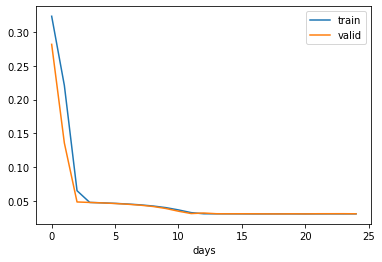

In [ ]:
plt.plot(history['train'],label = 'train')
plt.plot(history['val'],label = 'valid')
plt.legend()
plt.xlabel("days")

In [ ]:
train_loss_save = history['train']
val_loss_save = np.array(history['val'])

In [ ]:
np.save('/content/drive/MyDrive/Deeplearning/train_loss_std.npy',train_loss_save)
np.save('/content/drive/MyDrive/Deeplearning/val_loss_std.npy',val_loss_save)


# Test

In [ ]:

model.eval()
total = 0
correct = 0

with torch.no_grad():
    orig = []
    preds = []

    test_temp_loss = 0
    for data in test_loader:
        input = data[0]
        label = data[1]
        z = data[2]
        output = model(input,z)

        loss = criterion(output,label)
        test_temp_loss += loss.item()

        orig.append(label.cpu().detach().numpy() )
        preds.append(output.cpu().detach().numpy() )
    test_loss = test_temp_loss/ len(test_loader)


In [ ]:
print(test_loss)

0.03102980204857886


In [ ]:
len(preds)

8

In [ ]:
orig = np.vstack(orig)
preds = np.vstack(preds)

In [ ]:
preds[:,0].mean()

0.5297312

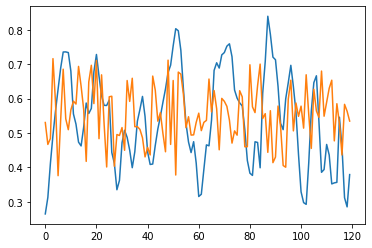

In [ ]:
plt.plot(orig[100])
plt.plot(preds[100])

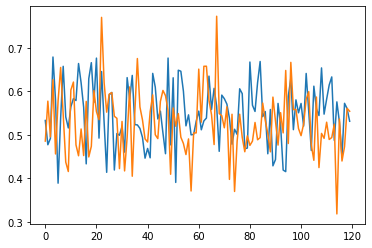

In [ ]:
plt.plot(preds[0])
# plt.plot(preds[100])
plt.plot(preds[200])

In [ ]:
np.save('/content/drive/MyDrive/Deeplearning/orig_std.npy',orig)
np.save('/content/drive/MyDrive/Deeplearning/preds_std.npy',preds)


Text(0, 0.5, 'index')

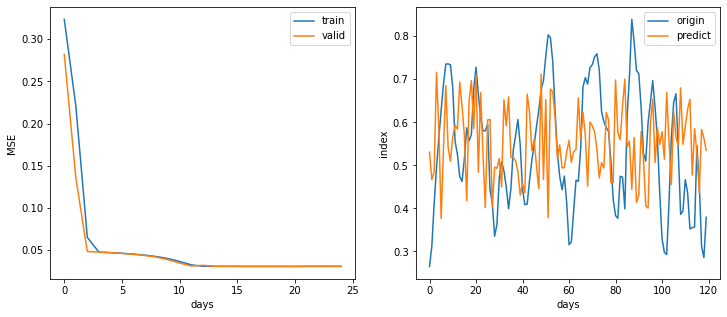

In [ ]:
fig,axes = plt.subplots(1,2,figsize = (12,5))
axes[0].plot(history['train'],label = 'train')
axes[0].plot(history['val'],label = 'valid')

axes[1].plot(orig[100],label = "origin")
axes[1].plot(preds[100],label= "predict")

axes[0].legend()
axes[1].legend()

axes[0].set_xlabel("days")
axes[1].set_xlabel("days")

axes[0].set_ylabel("MSE")
axes[1].set_ylabel("index")

## Total effectiveness

In [ ]:
corr = []
for i in range(120):
  r,p = scipy.stats.pearsonr(orig[:,i],preds[:,i])
  corr.append(r)

Text(0, 0.5, 'correlation coef')

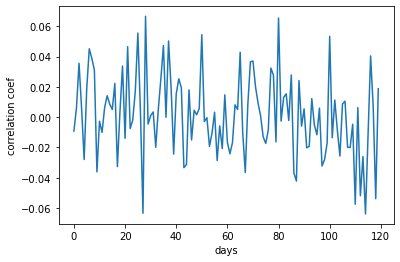

In [ ]:
plt.plot(corr)
plt.xlabel("days")
plt.ylabel("correlation coef")

## distribution

(array([5.9300e+02, 1.6640e+03, 3.5670e+03, 9.7090e+03, 1.6604e+04,
        2.7808e+04, 2.8282e+04, 2.7931e+04, 2.1788e+04, 1.6222e+04,
        1.0647e+04, 9.2800e+03, 6.1990e+03, 1.6650e+03, 8.3400e+02,
        8.3200e+02, 7.0800e+02, 3.4700e+02, 1.0000e+00, 1.1900e+02]),
 array([0.29475212, 0.3271258 , 0.35949945, 0.39187312, 0.4242468 ,
        0.45662045, 0.48899415, 0.5213678 , 0.55374146, 0.5861151 ,
        0.6184888 , 0.6508625 , 0.6832362 , 0.71560985, 0.7479835 ,
        0.7803572 , 0.81273085, 0.8451045 , 0.8774782 , 0.90985185,
        0.9422255 ], dtype=float32),
 <a list of 20 Patch objects>)

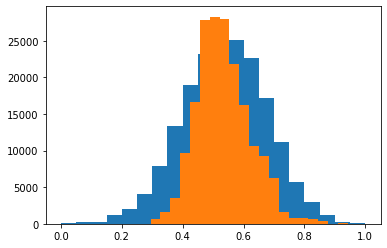

In [ ]:
plt.hist(orig.reshape(-1),bins = 20)
plt.hist(preds.reshape(-1),bins = 20)

(array([5.9300e+02, 1.6640e+03, 3.5670e+03, 9.7090e+03, 1.6604e+04,
        2.7808e+04, 2.8282e+04, 2.7931e+04, 2.1788e+04, 1.6222e+04,
        1.0647e+04, 9.2800e+03, 6.1990e+03, 1.6650e+03, 8.3400e+02,
        8.3200e+02, 7.0800e+02, 3.4700e+02, 1.0000e+00, 1.1900e+02]),
 array([0.29475212, 0.3271258 , 0.35949945, 0.39187312, 0.4242468 ,
        0.45662045, 0.48899415, 0.5213678 , 0.55374146, 0.5861151 ,
        0.6184888 , 0.6508625 , 0.6832362 , 0.71560985, 0.7479835 ,
        0.7803572 , 0.81273085, 0.8451045 , 0.8774782 , 0.90985185,
        0.9422255 ], dtype=float32),
 <a list of 20 Patch objects>)

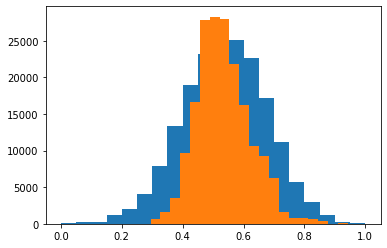

In [ ]:
plt.hist(orig.reshape(-1),bins = 20)
plt.hist(preds.reshape(-1),bins = 20)

Text(0, 0.5, 'counts')

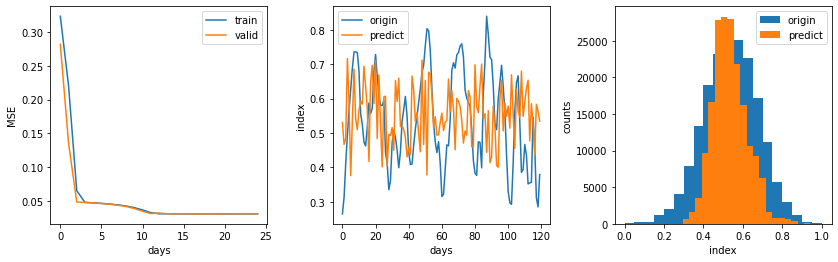

In [ ]:
fig,axes = plt.subplots(1,3,figsize = (14,4))
plt.subplots_adjust(wspace = 0.3)
axes[0].plot(history['train'],label = 'train')
axes[0].plot(history['val'],label = 'valid')

axes[1].plot(orig[100],label = "origin")
axes[1].plot(preds[100],label= "predict")

axes[2].hist(orig.reshape(-1),bins= 20,label = 'origin')
axes[2].hist(preds.reshape(-1),bins = 20,label = 'predict')

axes[0].legend()
axes[1].legend()
axes[2].legend()

axes[0].set_xlabel("days")
axes[1].set_xlabel("days")

axes[0].set_ylabel("MSE")
axes[1].set_ylabel("index")
axes[2].set_xlabel("index")
axes[2].set_ylabel("counts")

In [ ]:
orig.mean()

0.5370868

In [ ]:
preds.mean()

0.5354275

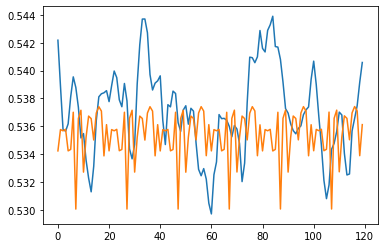

In [ ]:
plt.plot(orig.mean(axis = 0))
plt.plot(preds.mean(axis = 0))